# Graph Classification: AWE + GNN Hybrid Model

**Assignment:** Predict graph labels using Anonymous Walk Embeddings + Neural Network

**Paper:** Ivanov & Burnaev, "Anonymous Walk Embeddings", ICML 2018

**Dataset:** ogbg-molhiv (41,127 molecular graphs, binary classification, ROC-AUC metric)

**Group: 32**


|S.No.|Name                  |BITS ID                      |Contribution %|
|-----|----------------------|-----------------------------|--------------|
|1    |AKHILESH SHARMA       |2024aa05409                  |100           |
|2    |AMAN SINGH            |2024aa05301                  |100           |
|3    |NARASIMHA C V         |2024aa05428                  |100           |
|4    |RAHUL AGARWAL         |2024aa05676                  |100           |
|5    |RAJENDER KUMAR        |2024aa05173                  |100           |

## 1. Installation (Kaggle)

In [6]:
# Step 1: Check PyTorch version
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.8.0+cu126
CUDA: True


In [7]:
# Step 2: Install packages (run once, then restart kernel if needed)
!pip install -q ogb
!pip install -q torch-geometric
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.5.0+cu121.html

In [8]:
# Step 3: Imports
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import defaultdict
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# PyG imports
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

# OGB imports
from ogb.graphproppred import PygGraphPropPredDataset, Evaluator
from ogb.graphproppred.mol_encoder import AtomEncoder, BondEncoder

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 2. Load Dataset

In [9]:
# Fix for PyTorch 2.6+ (weights_only default changed)
import torch
_original_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _original_load(*args, **kwargs)
torch.load = _patched_load

dataset = PygGraphPropPredDataset(name='ogbg-molhiv', root='data/')
split_idx = dataset.get_idx_split()

train_idx = split_idx['train']
valid_idx = split_idx['valid']
test_idx = split_idx['test']

print(f"Total graphs: {len(dataset)}")
print(f"Train: {len(train_idx)}, Valid: {len(valid_idx)}, Test: {len(test_idx)}")
print(f"Node features: {dataset[0].x.shape[1]}")
print(f"Edge features: {dataset[0].edge_attr.shape[1]}")

Total graphs: 41127
Train: 32901, Valid: 4113, Test: 4113
Node features: 9
Edge features: 3


## 3. Anonymous Walk Embeddings (AWE)

**From the paper (Section 3.1):**
- Anonymous walk: Random walk where nodes are labeled by first occurrence order
- Example: walk [A→B→C→B] becomes [1→2→3→2]
- Graph embedding = normalized histogram of anonymous walk patterns

In [10]:
class AnonymousWalkEmbedding:
    """Feature-based AWE from Ivanov & Burnaev (ICML 2018)"""
    
    def __init__(self, max_length=8, walks_per_node=30):
        self.max_length = max_length
        self.walks_per_node = walks_per_node
        self.patterns = self._generate_all_patterns()
        self.pattern_to_idx = {p: i for i, p in enumerate(self.patterns)}
        self.dim = len(self.patterns)
    
    def _generate_all_patterns(self):
        """Generate all possible anonymous walk patterns (Bell numbers)"""
        all_patterns = []
        for length in range(2, self.max_length + 1):
            self._generate_length(length, [1], 1, all_patterns)
        return all_patterns
    
    def _generate_length(self, length, current, max_val, result):
        if len(current) == length:
            result.append(tuple(current))
            return
        for v in range(1, max_val + 2):
            self._generate_length(length, current + [v], max(max_val, v), result)
    
    def _random_walk(self, adj, start, length):
        walk = [start]
        node = start
        for _ in range(length - 1):
            neighbors = adj.get(node, [])
            if not neighbors:
                break
            node = random.choice(neighbors)
            walk.append(node)
        return walk
    
    def _to_anonymous(self, walk):
        mapping = {}
        result = []
        label = 1
        for node in walk:
            if node not in mapping:
                mapping[node] = label
                label += 1
            result.append(mapping[node])
        return tuple(result)
    
    def embed(self, data):
        """Compute AWE for a PyG graph"""
        edge_index = data.edge_index.cpu().numpy()
        num_nodes = data.num_nodes
        
        if num_nodes == 0 or edge_index.shape[1] == 0:
            return np.zeros(self.dim, dtype=np.float32)
        
        # Build adjacency
        adj = defaultdict(list)
        for i in range(edge_index.shape[1]):
            adj[edge_index[0, i]].append(edge_index[1, i])
        
        # Sample walks
        counts = np.zeros(self.dim, dtype=np.float32)
        total = 0
        
        for node in range(num_nodes):
            if not adj[node]:
                continue
            for _ in range(self.walks_per_node):
                for length in range(2, self.max_length + 1):
                    walk = self._random_walk(adj, node, length)
                    if len(walk) == length:
                        pattern = self._to_anonymous(walk)
                        if pattern in self.pattern_to_idx:
                            counts[self.pattern_to_idx[pattern]] += 1
                            total += 1
        
        if total > 0:
            counts /= total
        return counts

# Initialize
awe_model = AnonymousWalkEmbedding(max_length=8, walks_per_node=30)
print(f"AWE dimension: {awe_model.dim} patterns")

AWE dimension: 5294 patterns


In [11]:
def compute_awe_for_split(dataset, indices, awe_model):
    embeddings = []
    labels = []
    for idx in tqdm(indices, desc="AWE"):
        data = dataset[idx]
        emb = awe_model.embed(data)
        embeddings.append(emb)
        labels.append(data.y.item())
    return np.array(embeddings, dtype=np.float32), np.array(labels, dtype=np.float32)

print("Computing AWE embeddings (this takes ~20-30 min)...")
X_train_awe, y_train = compute_awe_for_split(dataset, train_idx, awe_model)
X_valid_awe, y_valid = compute_awe_for_split(dataset, valid_idx, awe_model)
X_test_awe, y_test = compute_awe_for_split(dataset, test_idx, awe_model)

print(f"Shapes: Train {X_train_awe.shape}, Valid {X_valid_awe.shape}, Test {X_test_awe.shape}")

Computing AWE embeddings (this takes ~20-30 min)...


AWE:   0%|          | 0/32901 [00:00<?, ?it/s]

AWE:   0%|          | 0/4113 [00:00<?, ?it/s]

AWE:   0%|          | 0/4113 [00:00<?, ?it/s]

Shapes: Train (32901, 5294), Valid (4113, 5294), Test (4113, 5294)


In [12]:
# Normalize AWE
scaler = StandardScaler()
X_train_awe = scaler.fit_transform(X_train_awe)
X_valid_awe = scaler.transform(X_valid_awe)
X_test_awe = scaler.transform(X_test_awe)

# Save embeddings
np.savez('awe_embeddings.npz',
         X_train=X_train_awe, X_valid=X_valid_awe, X_test=X_test_awe,
         y_train=y_train, y_valid=y_valid, y_test=y_test)
print("AWE embeddings saved!")

AWE embeddings saved!


## 4. GNN Encoder for Molecular Features

In [13]:
class GNNEncoder(nn.Module):
    """GNN to encode molecular node/edge features"""
    
    def __init__(self, hidden=256, layers=4, dropout=0.3):
        super().__init__()
        self.atom_encoder = AtomEncoder(hidden)
        self.convs = nn.ModuleList([GCNConv(hidden, hidden) for _ in range(layers)])
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(layers)])
        self.dropout = dropout
        self.out_dim = hidden * 2
    
    def forward(self, data):
        x = self.atom_encoder(data.x)
        edge_index = data.edge_index
        
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Pooling
        x_mean = global_mean_pool(x, data.batch)
        x_max = global_max_pool(x, data.batch)
        return torch.cat([x_mean, x_max], dim=1)

In [14]:
class HybridModel(nn.Module):
    """AWE + GNN Hybrid Model"""
    
    def __init__(self, awe_dim, gnn_hidden=256, gnn_layers=4, dropout=0.4):
        super().__init__()
        
        # GNN branch
        self.gnn = GNNEncoder(gnn_hidden, gnn_layers, dropout=0.3)
        
        # AWE branch
        self.awe_fc = nn.Sequential(
            nn.Linear(awe_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Combined classifier
        combined = self.gnn.out_dim + 256
        self.classifier = nn.Sequential(
            nn.Linear(combined, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
    
    def forward(self, data, awe):
        gnn_out = self.gnn(data)
        awe_out = self.awe_fc(awe)
        combined = torch.cat([gnn_out, awe_out], dim=1)
        return self.classifier(combined)

## 5. Data Loading

In [15]:
class HybridDataset:
    def __init__(self, pyg_data, indices, awe, labels):
        self.pyg = pyg_data
        self.idx = np.array(indices)
        self.awe = torch.FloatTensor(awe)
        self.y = torch.FloatTensor(labels).unsqueeze(1)
    
    def __len__(self):
        return len(self.idx)
    
    def __getitem__(self, i):
        return self.pyg[self.idx[i]], self.awe[i], self.y[i]

def collate_fn(batch):
    graphs, awes, labels = zip(*batch)
    return Batch.from_data_list(graphs), torch.stack(awes), torch.stack(labels)

BATCH = 128
train_ds = HybridDataset(dataset, train_idx.numpy(), X_train_awe, y_train)
valid_ds = HybridDataset(dataset, valid_idx.numpy(), X_valid_awe, y_valid)
test_ds = HybridDataset(dataset, test_idx.numpy(), X_test_awe, y_test)

train_loader = DataLoader(train_ds, BATCH, shuffle=True, collate_fn=collate_fn, num_workers=2)
valid_loader = DataLoader(valid_ds, BATCH, shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader = DataLoader(test_ds, BATCH, shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f"Batches - Train: {len(train_loader)}, Valid: {len(valid_loader)}, Test: {len(test_loader)}")

Batches - Train: 258, Valid: 33, Test: 33


## 6. Training

In [16]:
# Model
model = HybridModel(awe_dim=X_train_awe.shape[1]).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss (weighted for imbalance)
pos_weight = torch.tensor([(len(y_train) - y_train.sum()) / y_train.sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

Parameters: 2,192,641


In [17]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    preds, targets, total_loss = [], [], 0
    
    for graph, awe, y in loader:
        graph, awe, y = graph.to(device), awe.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(graph, awe)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item() * y.size(0)
        preds.extend(torch.sigmoid(out).detach().cpu().numpy().flatten())
        targets.extend(y.cpu().numpy().flatten())
    
    return total_loss / len(loader.dataset), roc_auc_score(targets, preds)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    preds, targets, total_loss = [], [], 0
    
    for graph, awe, y in loader:
        graph, awe, y = graph.to(device), awe.to(device), y.to(device)
        out = model(graph, awe)
        loss = criterion(out, y)
        
        total_loss += loss.item() * y.size(0)
        preds.extend(torch.sigmoid(out).cpu().numpy().flatten())
        targets.extend(y.cpu().numpy().flatten())
    
    return total_loss / len(loader.dataset), roc_auc_score(targets, preds), np.array(preds), np.array(targets)

In [18]:
EPOCHS = 100
PATIENCE = 15

best_auc = 0
best_state = None
patience_cnt = 0
history = {'train_loss': [], 'train_auc': [], 'valid_loss': [], 'valid_auc': []}

print("Training...")
print("=" * 75)

for epoch in range(EPOCHS):
    train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer)
    valid_loss, valid_auc, _, _ = evaluate(model, valid_loader, criterion)
    scheduler.step(valid_auc)
    
    history['train_loss'].append(train_loss)
    history['train_auc'].append(train_auc)
    history['valid_loss'].append(valid_loss)
    history['valid_auc'].append(valid_auc)
    
    if valid_auc > best_auc:
        best_auc = valid_auc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_cnt = 0
        flag = " << BEST"
    else:
        patience_cnt += 1
        flag = ""
    
    if (epoch + 1) % 5 == 0 or epoch == 0 or flag:
        print(f"Epoch {epoch+1:3d} | Train: {train_loss:.4f}, {train_auc:.4f} | Valid: {valid_loss:.4f}, {valid_auc:.4f}{flag}")
    
    if patience_cnt >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

print("=" * 75)
print(f"Best Validation AUC: {best_auc:.4f}")

Training...
Epoch   1 | Train: 1.2586, 0.6894 | Valid: 0.9786, 0.6559 << BEST
Epoch   2 | Train: 1.1512, 0.7490 | Valid: 0.8445, 0.7081 << BEST
Epoch   5 | Train: 0.9855, 0.8296 | Valid: 1.0165, 0.6751
Epoch   8 | Train: 0.8639, 0.8774 | Valid: 1.1004, 0.7258 << BEST
Epoch  10 | Train: 0.8088, 0.8978 | Valid: 1.5337, 0.6544
Epoch  11 | Train: 0.7362, 0.9154 | Valid: 1.4602, 0.7258 << BEST
Epoch  15 | Train: 0.5221, 0.9579 | Valid: 2.4287, 0.6957
Epoch  20 | Train: 0.3924, 0.9768 | Valid: 3.5304, 0.6981
Epoch  25 | Train: 0.3194, 0.9865 | Valid: 4.5288, 0.7170
Epoch  26 | Train: 0.3036, 0.9869 | Valid: 4.8720, 0.7385 << BEST
Epoch  29 | Train: 0.2924, 0.9886 | Valid: 4.9553, 0.7442 << BEST
Epoch  30 | Train: 0.2668, 0.9902 | Valid: 5.0509, 0.7317
Epoch  33 | Train: 0.2905, 0.9899 | Valid: 5.0343, 0.7444 << BEST
Epoch  35 | Train: 0.2249, 0.9928 | Valid: 5.6692, 0.7190
Epoch  36 | Train: 0.2539, 0.9920 | Valid: 5.3263, 0.7536 << BEST
Epoch  39 | Train: 0.2533, 0.9923 | Valid: 5.8858, 0.7

In [19]:
model.load_state_dict(best_state)
torch.save(best_state, 'best_model.pt')
print("Model saved!")

Model saved!


## 7. Final Evaluation

In [20]:
evaluator = Evaluator(name='ogbg-molhiv')

_, valid_auc, valid_preds, valid_y = evaluate(model, valid_loader, criterion)
_, test_auc, test_preds, test_y = evaluate(model, test_loader, criterion)

valid_res = evaluator.eval({'y_true': valid_y.reshape(-1, 1), 'y_pred': valid_preds.reshape(-1, 1)})
test_res = evaluator.eval({'y_true': test_y.reshape(-1, 1), 'y_pred': test_preds.reshape(-1, 1)})

print("\n" + "=" * 50)
print("FINAL RESULTS (OGB Evaluator)")
print("=" * 50)
print(f"Validation ROC-AUC: {valid_res['rocauc']:.4f}")
print(f"Test ROC-AUC:       {test_res['rocauc']:.4f}")
print("=" * 50)


FINAL RESULTS (OGB Evaluator)
Validation ROC-AUC: 0.7631
Test ROC-AUC:       0.7190


## 8. Visualization

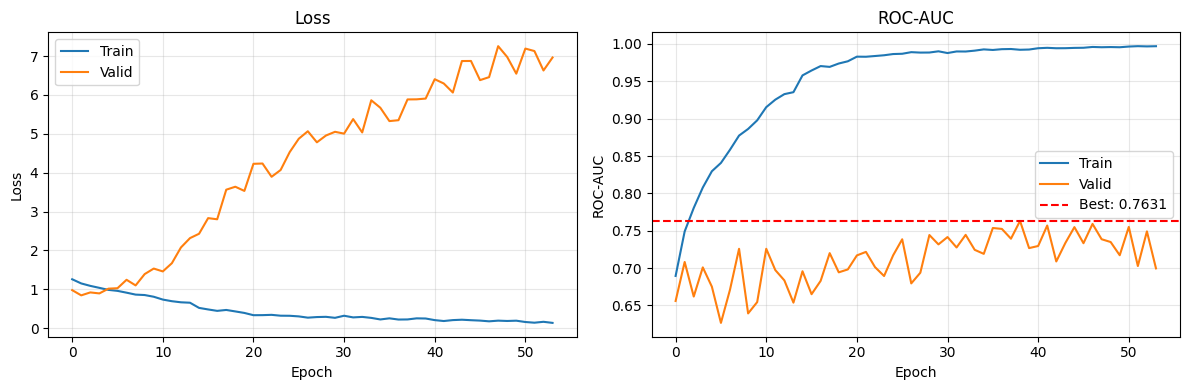

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history['train_loss'], label='Train')
ax[0].plot(history['valid_loss'], label='Valid')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(history['train_auc'], label='Train')
ax[1].plot(history['valid_auc'], label='Valid')
ax[1].axhline(y=best_auc, color='r', linestyle='--', label=f'Best: {best_auc:.4f}')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('ROC-AUC')
ax[1].set_title('ROC-AUC')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training.png', dpi=150)
plt.show()

## Summary

### Architecture
```
Graph --> AWE (4140-dim) --> FC(256) --+
      |                                |
      --> GNN (4-layer GCN) --> Pool --+--> Concat --> MLP --> Prediction
```

### Components
1. **AWE**: Anonymous Walk Embeddings (walks length 2-8, 30 walks/node)
2. **GNN**: 4-layer GCN with OGB AtomEncoder, mean+max pooling
3. **Classifier**: 3-layer MLP with BatchNorm and Dropout

### Optimizations
- Class weighting for imbalance (~25:1)
- Gradient clipping
- Learning rate scheduling
- Early stopping

### Reference
Ivanov & Burnaev. "Anonymous Walk Embeddings". ICML 2018.